In [1]:
import numpy as np
from sympy import lambdify,diff,exp,latex
from sympy.abc import x,y
import matplotlib.pyplot as plt

In [2]:
num = 301
x_array = np.linspace(-3,3,num)
y_array = np.linspace(-3,3,num)
xx,yy = np.meshgrid(x_array,y_array)

In [3]:
f_xy = 3 * (1 - x)**2 * exp(-x**2 - (y + 1)**2) \
    - 10 * (x / 5 - x**3 - y**5) * exp(-x**2 - y**2) \
    - 1/3 * exp(-(x + 1)**2 - y**2)
f_xy

3*(1 - x)**2*exp(-x**2 - (y + 1)**2) - (-10*x**3 + 2*x - 10*y**5)*exp(-x**2 - y**2) - 0.333333333333333*exp(-y**2 - (x + 1)**2)

In [4]:
f_xy_fcn = lambdify((x,y),f_xy)
f_xy_zz = f_xy_fcn(xx,yy)

In [5]:
df_dx = f_xy.diff(x)
df_dx

-6*x*(1 - x)**2*exp(-x**2 - (y + 1)**2) + 2*x*(-10*x**3 + 2*x - 10*y**5)*exp(-x**2 - y**2) - (2 - 30*x**2)*exp(-x**2 - y**2) - 0.333333333333333*(-2*x - 2)*exp(-y**2 - (x + 1)**2) + 3*(2*x - 2)*exp(-x**2 - (y + 1)**2)

In [6]:
df_dx_fcn = lambdify((x,y),df_dx)
df_dx_zz = df_dx_fcn(xx,yy)

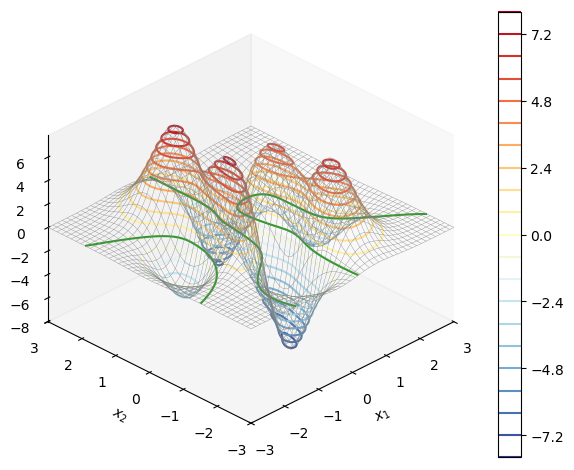

In [7]:
fig,ax = plt.subplots(subplot_kw = {'projection':'3d'})

ax.plot_wireframe(xx,yy,df_dx_zz,color = '0.5',lw = 0.25)
colorbar = ax.contour(xx,yy,df_dx_zz,20,cmap = 'RdYlBu_r')

ax.contour(xx,yy,df_dx_zz,levels = [0],colors = '#339933',linestyles = '-')

fig.colorbar(colorbar,ax = ax)
ax.set_proj_type('ortho')  # 设置投影类型为正交
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
ax.set_zlabel('$f_{x1}(x_1,x_2)$')  # 设置 z 轴标签
plt.tight_layout()  # 紧凑布局
ax.set_xlim(xx.min(), xx.max())  # 设置 x 轴范围
ax.set_ylim(yy.min(), yy.max())  # 设置 y 轴范围
ax.view_init(azim=-135, elev=30)  # 设置视角
ax.grid(False)  # 关闭网格线
plt.show()  # 显示图像

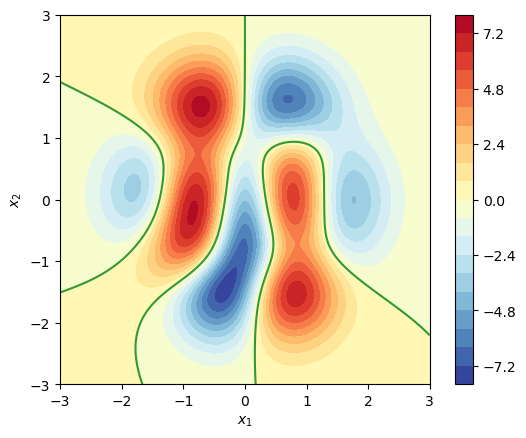

In [8]:
fig,ax = plt.subplots()

colorbar = ax.contourf(xx,yy,df_dx_zz,20,cmap='RdYlBu_r')
ax.contour(xx,yy,df_dx_zz,levels = [0],colors = '#339933',linestyles = '-')

fig.colorbar(colorbar,ax = ax)
ax.set_xlim(xx.min(),xx.max())
ax.set_ylim(yy.min(),yy.max())
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_aspect('equal',adjustable = 'box')
plt.show()

In [9]:
df_dy= f_xy.diff(y)
df_dy

50*y**4*exp(-x**2 - y**2) + 2*y*(-10*x**3 + 2*x - 10*y**5)*exp(-x**2 - y**2) + 0.666666666666667*y*exp(-y**2 - (x + 1)**2) + 3*(1 - x)**2*(-2*y - 2)*exp(-x**2 - (y + 1)**2)

In [10]:
df_dy_fcn = lambdify([x,y],df_dy)
df_dy_zz = df_dy_fcn(xx,yy)

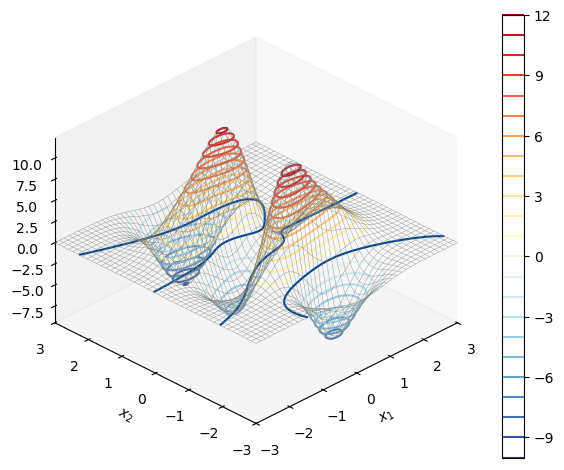

In [11]:
fig,ax = plt.subplots(subplot_kw = {'projection':'3d'})

ax.plot_wireframe(xx,yy,df_dy_zz,color = '0.5',lw = 0.25)
colorbar = ax.contour(xx,yy,df_dy_zz,20,cmap = 'RdYlBu_r')

ax.contour(xx,yy,df_dy_zz,levels = [0],colors = '#00448A')

fig.colorbar(colorbar,ax = ax)
ax.set_proj_type('ortho')  # 设置投影类型为正交
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
ax.set_zlabel('$f_{x1}(x_1,x_2)$')  # 设置 z 轴标签
plt.tight_layout()  # 紧凑布局
ax.set_xlim(xx.min(), xx.max())  # 设置 x 轴范围
ax.set_ylim(yy.min(), yy.max())  # 设置 y 轴范围
ax.view_init(azim=-135, elev=30)  # 设置视角
ax.grid(False)  # 关闭网格线
plt.show()  # 显示图像

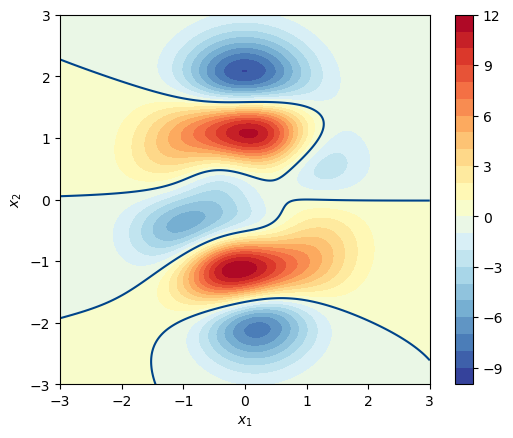

In [12]:
fig,ax = plt.subplots()

colorbar = ax.contourf(xx,yy,df_dy_zz,20,cmap='RdYlBu_r')
ax.contour(xx,yy,df_dy_zz,levels = [0],colors = '#00448A',linestyles = '-')

fig.colorbar(colorbar,ax = ax)
ax.set_xlim(xx.min(),xx.max())
ax.set_ylim(yy.min(),yy.max())
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_aspect('equal',adjustable = 'box')
plt.show()

In [25]:
def plot_surface(xx,yy,surface,title_txt):
    fig = plt.figure(figsize = plt.figaspect(0.5))#配置长宽比
    ax = fig.add_subplot(1,2,1,projection = '3d')
    ax.plot_wireframe(xx,yy,surface,color = '0.5',linewidth = 0.25)
    colorbar = ax.contour(xx,yy,surface,20,cmap = 'RdYlBu_r')

    ax.set_proj_type('ortho')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_zlabel(title_txt)
    ax.set_xlim(xx.min(),xx.max())
    ax.set_ylim(yy.min(),yy.max())
    ax.view_init(azim = -135,elev = 30)
    ax.grid(False)

    ax = fig.add_subplot(1,2,2)
    colorbar = ax.contourf(xx,yy,surface,20,cmap = 'RdYlBu_r')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_xlim(xx.min(),xx.max())
    ax.set_ylim(yy.min(),yy.max())
    plt.gca().set_aspect('equal',adjustable = 'box')

In [31]:
d2f_dxdy = f_xy.diff(x,y)
d2f_dxdy

-100*x*y**4*exp(-x**2 - y**2) + 8*x*y*(5*x**3 - x + 5*y**5)*exp(-x**2 - y**2) + 12*x*(x - 1)**2*(y + 1)*exp(-x**2 - (y + 1)**2) - 1.33333333333333*y*(x + 1)*exp(-y**2 - (x + 1)**2) - 4*y*(15*x**2 - 1)*exp(-x**2 - y**2) - 12*(x - 1)*(y + 1)*exp(-x**2 - (y + 1)**2)

In [27]:
d2f_dxdy_fcn = lambdify([x,y],d2f_dxdy)#转换为可执行的匿名函数
d2f_dxdy_zz = d2f_dxdy_fcn(xx,yy)

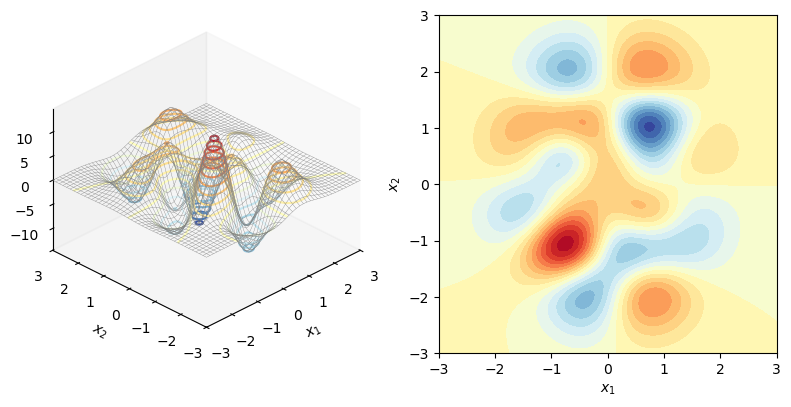

In [28]:
title_txt = '$f_{x1,x2}(x1,x2)$'
plot_surface(xx,yy,d2f_dxdy_zz,title_txt)

In [34]:
d2f_dxdx = f_xy.diff(x,2)
d2f_dxdx

12*x**2*(x - 1)**2*exp(-x**2 - (y + 1)**2) + 8*x**2*(5*x**3 - x + 5*y**5)*exp(-x**2 - y**2) - 24*x*(x - 1)*exp(-x**2 - (y + 1)**2) - 8*x*(15*x**2 - 1)*exp(-x**2 - y**2) + 60*x*exp(-x**2 - y**2) - 6*(x - 1)**2*exp(-x**2 - (y + 1)**2) - 1.33333333333333*(x + 1)**2*exp(-y**2 - (x + 1)**2) - 4*(5*x**3 - x + 5*y**5)*exp(-x**2 - y**2) + 6*exp(-x**2 - (y + 1)**2) + 0.666666666666667*exp(-y**2 - (x + 1)**2)

In [35]:
d2f_dxdx_fcn = lambdify([x,y],d2f_dxdx)
d2f_dxdx_zz = d2f_dxdx_fcn(xx,yy)

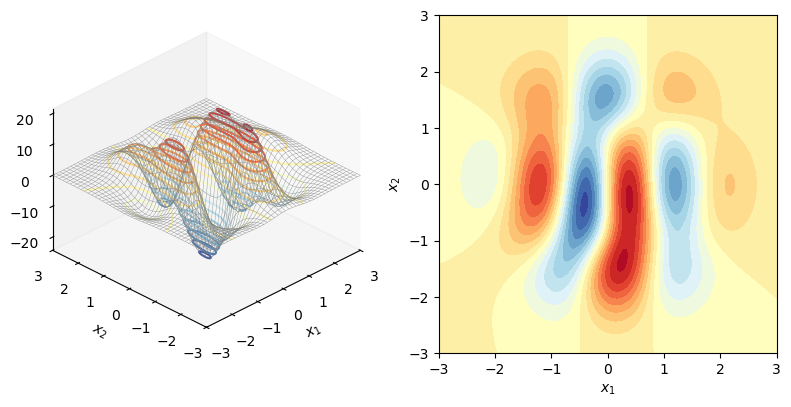

In [37]:
title_txt = '$f_{x1,x1}(x1,x2)$'
plot_surface(xx,yy,d2f_dxdx_zz,title_txt)

In [38]:
d2f_dydy = f_xy.diff(y,2)
d2f_dydy

-200*y**5*exp(-x**2 - y**2) + 200*y**3*exp(-x**2 - y**2) + 8*y**2*(5*x**3 - x + 5*y**5)*exp(-x**2 - y**2) - 1.33333333333333*y**2*exp(-y**2 - (x + 1)**2) + 12*(x - 1)**2*(y + 1)**2*exp(-x**2 - (y + 1)**2) - 6*(x - 1)**2*exp(-x**2 - (y + 1)**2) - 4*(5*x**3 - x + 5*y**5)*exp(-x**2 - y**2) + 0.666666666666667*exp(-y**2 - (x + 1)**2)

In [39]:
d2f_dydy_fcn = lambdify([x,y],d2f_dydy)
d2f_dydy_zz = d2f_dydy_fcn(xx,yy)

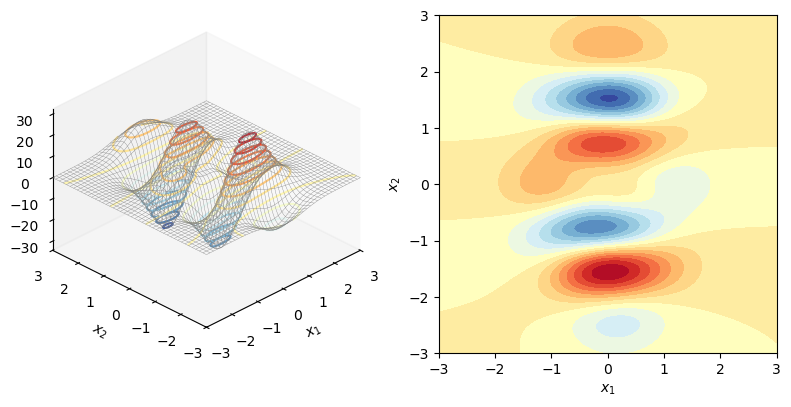

In [40]:
title_txt = '$f_{x2,x2}(x1,x2)$'
plot_surface(xx,yy,d2f_dydy_zz,title_txt)

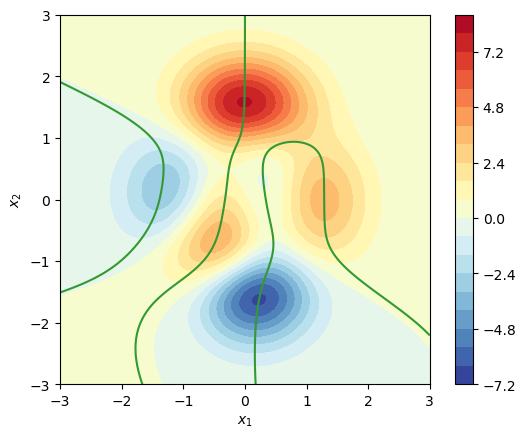

In [59]:
fig,ax = plt.subplots()

colorbar = ax.contourf(xx,yy,f_xy_zz,20,cmap = 'RdYlBu_r')
fig.colorbar(colorbar,ax = ax)

ax.contour(xx,yy,df_dx_zz,levels = [0],colors = ['#339933'])

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_xlim(xx.min(),xx.max())
ax.set_ylim(yy.min(),yy.max())
plt.gca().set_aspect('equal',adjustable = 'box')
plt.show()

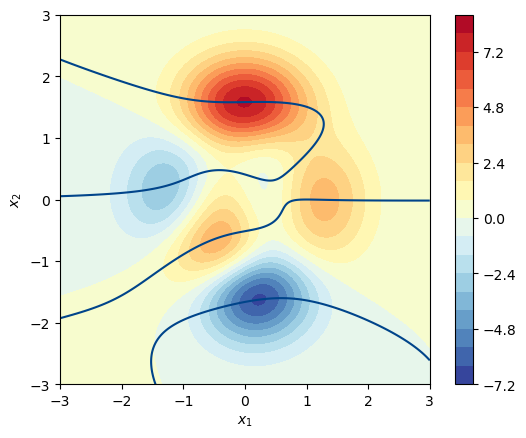

In [60]:
fig,ax = plt.subplots()

colorbar = ax.contourf(xx,yy,f_xy_zz,20,cmap = 'RdYlBu_r')
fig.colorbar(colorbar,ax = ax)

ax.contour(xx,yy,df_dy_zz,levels = [0],colors = ['#00448A'])

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_xlim(xx.min(),xx.max())
ax.set_ylim(yy.min(),yy.max())
plt.gca().set_aspect('equal',adjustable = 'box')
plt.show()

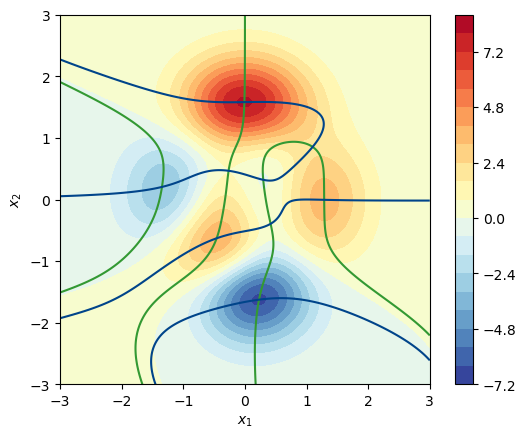

In [61]:
fig,ax = plt.subplots()

colorbar = ax.contourf(xx,yy,f_xy_zz,20,cmap = 'RdYlBu_r')
fig.colorbar(colorbar,ax = ax)

ax.contour(xx,yy,df_dx_zz,levels = [0],colors = ['#339933'])
ax.contour(xx,yy,df_dy_zz,levels = [0],colors = ['#00448A'])


ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_xlim(xx.min(),xx.max())
ax.set_ylim(yy.min(),yy.max())
plt.gca().set_aspect('equal',adjustable = 'box')
plt.show()

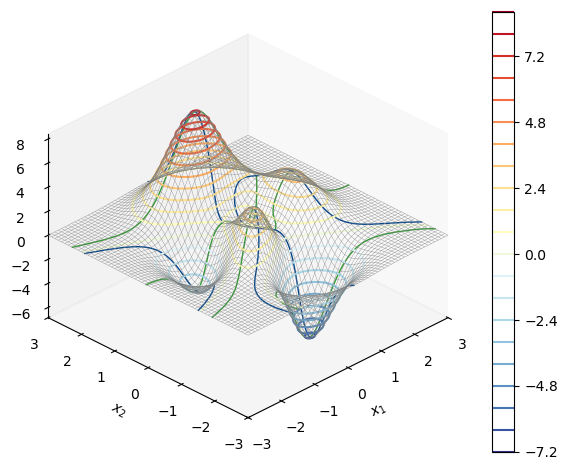

In [72]:
fig,ax = plt.subplots(subplot_kw = {'projection':'3d'})

CS_y = ax.contour(xx,yy,df_dy_zz,levels = [0],colors = '#339933')
CS_x = ax.contour(xx,yy,df_dx_zz,levels = [0],colors = '#339933')
ax.cla()

ax.plot_wireframe(xx,yy,f_xy_zz,color = '0.5',rstride = 5,cstride = 5,linewidth = 0.25)
colorbar = ax.contour(xx,yy,f_xy_zz,20,cmap = 'RdYlBu_r')

fig.colorbar(colorbar,ax = ax)

for i in range(0,len(CS_y.allsegs[0])):#取出所有的线段,len计数(是n不是n-1),然后遍历 如果有多个等高线[0]是对应最小的levels,[1],[2]依此类推
    contour_points_x_y = CS_y.allsegs[0][i]#取出整条线的坐标,后面计算的是整条线
    contour_points_z = f_xy_fcn(contour_points_x_y[:,0],contour_points_x_y[:,1])
    ax.plot3D(contour_points_x_y[:,0],contour_points_x_y[:,1],contour_points_z,color = '#339933',linewidth = 1)

for i in range(0,len(CS_x.allsegs[0])):
    contour_points_x_y = CS_x.allsegs[0][i]
    contour_points_z = f_xy_fcn(contour_points_x_y[:,0],contour_points_x_y[:,1])
    ax.plot3D(contour_points_x_y[:,0],contour_points_x_y[:,1],contour_points_z,color = '#00448A',linewidth = 1)

ax.set_proj_type('ortho')  # 设置正交投影
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
ax.set_zlabel('$f(x_1,x_2)$')  # 设置 z 轴标签

ax.set_xlim(xx.min(), xx.max())  # 设置 x 轴范围
ax.set_ylim(yy.min(), yy.max())  # 设置 y 轴范围
ax.view_init(azim=-135, elev=30)  # 设置视角
plt.tight_layout()  # 紧凑布局
ax.grid(False)  # 关闭网格线
plt.show()  # 显示图像